In [84]:
#!/usr/bin/env python3
"""
GEV checker for Kafka pipeline block maxima.

Examples
--------
# 1) Use block_maxima.csv directly (recommended)
python3 gev_check.py \
  --metrics-dir /app/merged-data/merge-metrics \
  --metric producer_application --scope global

# 2) Build maxima from Parquet if block_maxima.csv is absent/insufficient
python3 gev_check.py \
  --parquet-dir /app/consumer-merge-data/consumer-result \
  --metric consumer_application --scope consumer_pod --pod consumer-sts-0

# 3) Save plots and results to a folder
python3 gev_check.py \
  --metrics-dir /app/merged-data/merge-metrics \
  --metric producer_consumer --scope producer_pod --pod producer-sts-2 \
  --outdir ./gev_artifacts --plots
"""



'\nGEV checker for Kafka pipeline block maxima.\n\nExamples\n--------\n# 1) Use block_maxima.csv directly (recommended)\npython3 gev_check.py   --metrics-dir /app/merged-data/merge-metrics   --metric producer_application --scope global\n\n# 2) Build maxima from Parquet if block_maxima.csv is absent/insufficient\npython3 gev_check.py   --parquet-dir /app/consumer-merge-data/consumer-result   --metric consumer_application --scope consumer_pod --pod consumer-sts-0\n\n# 3) Save plots and results to a folder\npython3 gev_check.py   --metrics-dir /app/merged-data/merge-metrics   --metric producer_consumer --scope producer_pod --pod producer-sts-2   --outdir ./gev_artifacts --plots\n'

In [85]:
import os
import sys
import argparse
import time
import numpy as np
import pandas as pd
from typing import Optional, Set, List
from datetime import datetime
# Optional SciPy / Matplotlib imports
try:
    from scipy.stats import genextreme, kstest, probplot
    SCIPY_OK = True
except Exception:
    SCIPY_OK = False

try:
    import matplotlib.pyplot as plt
    MPL_OK = True
except Exception:
    MPL_OK = False



In [86]:
METRIC_CHOICES = ("producer_consumer", "consumer_application", "producer_application")
SCOPE_CHOICES  = ("global", "consumer_pod", "producer_pod")

In [87]:
def read_block_maxima_csv(metrics_dir: str) -> Optional[pd.DataFrame]:
    path = os.path.join(metrics_dir, "/Users/soheila/PycharmProjects/PipelineProject/RealTime-Streaming-Pipeline/results/20250901_134420/merge/merge-sts-0_merge-metrics/block_maxima.csv")
    if not os.path.exists(path):
        return None
    try:
        df = pd.read_csv(path)
        return df
    except Exception as e:
        print(f"[WARN] Could not read {path}: {e}")
        return None


In [88]:
def list_parquet_files(parquet_dir: str, recursive: bool = True) -> List[str]:
    """
    Recursively collect all parquet files inside a directory, no matter how deeply nested.

    Args:
        parquet_dir (str): The root directory to search in.
        recursive (bool): If True, search all nested subdirectories. If False, only search top level.

    Returns:
        List[str]: Sorted list of absolute paths to parquet files.
    """
    out = []
    if recursive:
        # Traverse all subdirectories
        for root, _, files in os.walk(parquet_dir):
            for f in files:
                if f.endswith(".parquet") and not f.startswith(".tmp_"):
                    out.append(os.path.join(root, f))
    else:
        # Only look at the top-level directory
        for f in os.listdir(parquet_dir):
            if f.endswith(".parquet") and not f.startswith(".tmp_"):
                out.append(os.path.join(parquet_dir, f))

    return sorted(out)


In [89]:
def load_parquet_columns(parquet_path: str, needed_cols: Set[str]) -> Optional[pd.DataFrame]:
    # Try schema-inspection via pyarrow first (faster if available)
    try:
        import pyarrow.parquet as pq
        schema = pq.read_schema(parquet_path)
        have = set(schema.names)
        cols = list(needed_cols & have)
        if not cols:
            return pd.DataFrame()
        return pd.read_parquet(parquet_path, columns=cols)
    except Exception:
        # Fallback: read-all then subset
        try:
            df = pd.read_parquet(parquet_path)
            keep = list(needed_cols & set(df.columns))
            return df[keep] if keep else pd.DataFrame()
        except Exception as e2:
            print(f"[WARN] Failed to read {os.path.basename(parquet_path)}: {e2}")
            return None

In [90]:
def metric_series(frame: pd.DataFrame, metric: str) -> pd.Series:
    """
    Create the latency series (in seconds) for the given metric from a DataFrame slice.
    """
    if metric == "producer_consumer":
        need = {"producer_timestamp", "consumer_receive_timestamp"}
        if not need.issubset(frame.columns):
            return pd.Series([], dtype=float)
        s = (frame["consumer_receive_timestamp"] - frame["producer_timestamp"])
        return pd.to_numeric(s, errors="coerce")

    if metric == "consumer_application":
        if "application_latency_seconds" in frame.columns:
            return pd.to_numeric(frame["application_latency_seconds"], errors="coerce")
        need = {"application_timestamp", "consumer_receive_timestamp"}
        if not need.issubset(frame.columns):
            return pd.Series([], dtype=float)
        s = (frame["application_timestamp"] - frame["consumer_receive_timestamp"])
        return pd.to_numeric(s, errors="coerce")

    if metric == "producer_application":
        if "end_to_end_latency_seconds" in frame.columns:
            return pd.to_numeric(frame["end_to_end_latency_seconds"], errors="coerce")
        need = {"application_timestamp", "producer_timestamp"}
        if not need.issubset(frame.columns):
            return pd.Series([], dtype=float)
        s = (frame["application_timestamp"] - frame["producer_timestamp"])
        return pd.to_numeric(s, errors="coerce")

    return pd.Series([], dtype=float)

In [91]:
def build_block_maxima_from_parquet(
    parquet_dir: str,
    metric: str,
    scope: str,
    pod: Optional[str]
) -> Optional[pd.DataFrame]:
    """
    Treat EACH parquet file as one block and compute max latency for the requested
    (metric, scope[, pod]). Returns a DataFrame with:
      block_id, file_name, metric, scope, pod, block_max_value, rows_in_block, computed_at
    """
    assert metric in METRIC_CHOICES
    assert scope in SCOPE_CHOICES

    needed = {
        "producer_timestamp", "consumer_receive_timestamp",
        "application_timestamp", "application_latency_seconds",
        "end_to_end_latency_seconds",
        "producer_pod", "consumer_pod",
    }

    rows = []
    files = list_parquet_files(parquet_dir)
    if not files:
        print(f"[INFO] No parquet files found under {parquet_dir}")
        return pd.DataFrame()

    for p in files:
        df = load_parquet_columns(p, needed)
        if df is None or df.empty:
            continue

        # normalize numeric columns if present
        for col in ["producer_timestamp","consumer_receive_timestamp","application_timestamp",
                    "application_latency_seconds","end_to_end_latency_seconds"]:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors="coerce")

        # normalize pods
        for c in ["producer_pod","consumer_pod"]:
            if c in df.columns:
                df[c] = df[c].astype("string")

        # scope selection
        file_name = os.path.basename(p)
        block_id = os.path.splitext(file_name)[0]
        computed_at = time.time()

        if scope == "global":
            s = metric_series(df, metric)
            s = s.replace([np.inf,-np.inf], np.nan).dropna()
            s = s[s >= 0]
            if s.empty:
                continue
            rows.append({
                "block_id": block_id,
                "file_name": file_name,
                "metric": metric,
                "scope": "global",
                "pod": "",
                "block_max_value": float(s.max()),
                "rows_in_block": int(s.shape[0]),
                "computed_at": computed_at
            })


            
        elif scope == "consumer_pod":
            if "consumer_pod" not in df.columns or df["consumer_pod"].dropna().empty:
                continue
            if pod:
                sub = df[df["consumer_pod"].astype("string") == str(pod)]
                if sub.empty:
                    continue
                s = metric_series(sub, metric).replace([np.inf,-np.inf], np.nan).dropna()
                s = s[s >= 0]
                if s.empty: 
                    continue
                rows.append({
                    "block_id": block_id, "file_name": file_name,
                    "metric": metric, "scope": "consumer_pod", "pod": str(pod),
                    "block_max_value": float(s.max()), "rows_in_block": int(s.shape[0]),
                    "computed_at": computed_at
                })
            else:
                for pod_val, sub in df.dropna(subset=["consumer_pod"]).groupby(df["consumer_pod"].astype("string")):
                    s = metric_series(sub, metric).replace([np.inf,-np.inf], np.nan).dropna()
                    s = s[s >= 0]
                    if s.empty: 
                        continue
                    rows.append({
                        "block_id": block_id, "file_name": file_name,
                        "metric": metric, "scope": "consumer_pod", "pod": str(pod_val),
                        "block_max_value": float(s.max()), "rows_in_block": int(s.shape[0]),
                        "computed_at": computed_at
                    })
        else:  # producer_pod
            if "producer_pod" not in df.columns or df["producer_pod"].dropna().empty:
                continue
            if pod:
                sub = df[df["producer_pod"].astype("string") == str(pod)]
                if sub.empty:
                    continue
                s = metric_series(sub, metric).replace([np.inf,-np.inf], np.nan).dropna()
                s = s[s >= 0]
                if s.empty: 
                    continue
                rows.append({
                    "block_id": block_id, "file_name": file_name,
                    "metric": metric, "scope": "producer_pod", "pod": str(pod),
                    "block_max_value": float(s.max()), "rows_in_block": int(s.shape[0]),
                    "computed_at": computed_at
                })
            else:
                for pod_val, sub in df.dropna(subset=["producer_pod"]).groupby(df["producer_pod"].astype("string")):
                    s = metric_series(sub, metric).replace([np.inf,-np.inf], np.nan).dropna()
                    s = s[s >= 0]
                    if s.empty: 
                        continue
                    rows.append({
                        "block_id": block_id, "file_name": file_name,
                        "metric": metric, "scope": "producer_pod", "pod": str(pod_val),
                        "block_max_value": float(s.max()), "rows_in_block": int(s.shape[0]),
                        "computed_at": computed_at
                    })

    return pd.DataFrame(rows)



In [92]:
def filter_series_from_block_maxima(
    df: pd.DataFrame, metric: str, scope: str, pod: Optional[str]
) -> np.ndarray:
    if df is None or df.empty:
        return np.array([])
    need = {"metric","scope","block_max_value"}
    if not need.issubset(df.columns):
        return np.array([])

    sub = df[(df["metric"] == metric) & (df["scope"] == scope)]
    if scope in ("consumer_pod","producer_pod"):
        pod = "" if pod is None else str(pod)
        if "pod" not in sub.columns:
            return np.array([])
        sub = sub[sub["pod"].fillna("") == pod]

    vals = pd.to_numeric(sub["block_max_value"], errors="coerce").dropna().astype(float).values
    vals = vals[vals >= 0]
    return vals

In [93]:
def fit_and_report(data: np.ndarray, metric: str, scope: str, pod: Optional[str],
                   outdir: Optional[str], make_plots: bool, min_blocks: int):
    label = f"{metric} | {scope}" + ("" if scope == "global" else f" | pod={pod or ''}")
    print(f"\n=== GEV check for: {label} ===")

    n = len(data)
    print(f"Blocks available: {n}")
    if n < min_blocks:
        print(f"[INFO] Not enough blocks (need >= {min_blocks}). Aborting fit.")
        return

    if not SCIPY_OK:
        print("[ERROR] SciPy is not available. Install with `pip install scipy` and rerun.")
        return

    c, loc, scale = genextreme.fit(data)  # SciPy uses 'c' where xi = -c
    D, p = kstest(data, 'genextreme', args=(c, loc, scale))

    print(f"Fit parameters:")
    print(f"  shape c   = {c: .6f}  (xi = {-c: .6f})")
    print(f"  location  = {loc: .6f}")
    print(f"  scale     = {scale: .6f}")
    print(f"KS test: D={D:.6f}, p={p:.6f}")

    # Basic return levels (quantiles)
    for q in (0.90, 0.95, 0.99, 0.999):
        zq = genextreme.ppf(q, c, loc=loc, scale=scale)
        print(f"  q={q:.3f} -> return level ≈ {zq:.6f} seconds")

    # Write CSV row
    if outdir:
        os.makedirs(outdir, exist_ok=True)
        out_csv = os.path.join(outdir, "gev_check_results.csv")
        row = pd.DataFrame([{
            "timestamp": datetime.utcnow().strftime('%Y-%m-%dT%H%M%S'),
            "metric": metric, "scope": scope, "pod": (pod or ""),
            "n_blocks": n, "shape_c": c, "xi": -c, "location_mu": loc, "scale_beta": scale,
            "ks_D": D, "ks_pvalue": p
        }])
        if not os.path.exists(out_csv):
            row.to_csv(out_csv, index=False)
        else:
            row.to_csv(out_csv, mode='a', header=False, index=False)
        print(f"[OK] Wrote results to: {out_csv}")

    # Optional plots
    if make_plots and MPL_OK:
        x = np.sort(data)
        # PDF overlay
        xs = np.linspace(x.min(), x.max(), 300)
        pdf = genextreme.pdf(xs, c, loc=loc, scale=scale)

        plt.figure()
        # empirical histogram
        plt.hist(x, bins=max(10, int(np.sqrt(n))), density=True, alpha=0.5)
        plt.plot(xs, pdf, linewidth=2)
        plt.title(f"PDF fit: {label}")
        if outdir:
            f1 = os.path.join(outdir, f"pdf_{metric}_{scope}_{(pod or 'global')}.png")
            plt.savefig(f1, bbox_inches="tight")
            print(f"[OK] Saved {f1}")
        else:
            plt.show()

        # QQ plot (using SciPy probplot on transformed variable)
        plt.figure()
        # Transform data to standard GEV quantiles via CDF then inverse of standard
        # Simpler: compare theoretical vs empirical quantiles directly
        # Build theoretical quantiles from fitted GEV
        probs = (np.arange(1, n+1) - 0.5) / n
        theo = genextreme.ppf(probs, c, loc=loc, scale=scale)
        plt.plot(theo, x, '.', ms=4)
        mn = min(x.min(), theo.min()); mx = max(x.max(), theo.max())
        plt.plot([mn, mx], [mn, mx], '--')
        plt.xlabel("Theoretical quantiles (GEV)")
        plt.ylabel("Empirical quantiles")
        plt.title(f"QQ plot: {label}")
        if outdir:
            f2 = os.path.join(outdir, f"qq_{metric}_{scope}_{(pod or 'global')}.png")
            plt.savefig(f2, bbox_inches="tight")
            print(f"[OK] Saved {f2}")
        else:
            plt.show()
    elif make_plots and not MPL_OK:
        print("[WARN] Matplotlib not available; skipping plots.")


In [94]:

def parse_args(argv=None):
    p = argparse.ArgumentParser(
        description="Check GEV fit on block maxima built from consumer parquet files."
    )
    p.add_argument("--metrics-dir", default="./metrics",
                   help="Directory where outputs go (block_maxima snapshot + GEV results).")
    p.add_argument("--parquet-dir", default="./parquet",
                   help="Directory containing parquet batches (each file = one block).")
    p.add_argument("--metric", required=True,
                   choices=["producer_consumer", "consumer_application", "producer_application"],
                   help="Latency metric to analyze.")
    p.add_argument("--scope", required=True,
                   choices=["global", "consumer_pod", "producer_pod"],
                   help="Aggregation scope.")
    p.add_argument("--pod", default=None,
                   help="When scope is consumer_pod or producer_pod, optionally filter to a single pod.")
    p.add_argument("--min-blocks", type=int, default=30,
                   help="Minimum number of blocks required to fit GEV.")
    p.add_argument("--outdir", default="./plots",
                   help="Directory to write plots if --plots is given.")
    p.add_argument("--plots", action="store_true",
                   help="Save a histogram+pdf plot if matplotlib is available.")
    return p.parse_args(argv)

In [95]:

def main(argv=None):
    # Parse args (friendly behavior inside notebooks)
    try:
        args = parse_args(argv)
    except SystemExit as e:
        if "ipykernel" in sys.modules:
            print("[ERROR] Missing required args --metric and --scope. "
                  "Call main([...]) with explicit arguments if running in a notebook.")
            return 2
        raise

    # Ensure dirs exist
    if args.metrics_dir:
        os.makedirs(args.metrics_dir, exist_ok=True)
    if args.outdir:
        os.makedirs(args.outdir, exist_ok=True)

    # 1) Build block-maxima snapshot from Parquet for the requested metric/scope[/pod]
    maxima_df = build_block_maxima_table(
        parquet_dir=args.parquet_dir,
        metric=args.metric,
        scope=args.scope,
        pod=args.pod
    )

    if maxima_df is None or maxima_df.empty:
        print("[WARN] No block maxima found. Check parquet directory and that files contain the required columns.")
        return 0

    snap_name = "block_maxima_snapshot_{m}_{s}{p}.csv".format(
        m=args.metric,
        s=args.scope,
        p=("_" + args.pod) if args.pod else ""
    )
    snap_path = os.path.join(args.metrics_dir, snap_name)
    maxima_df.to_csv(snap_path, index=False)
    print(f"[INFO] Wrote block maxima snapshot: {snap_path} (rows={len(maxima_df)})")

    # 2) Fit GEV (SciPy required) — your helper should raise if SciPy is missing or not enough blocks
    try:
        result_row_df, fig = fit_gev_on_block_maxima(maxima_df, min_blocks=args.min_blocks)
    except Exception as e:
        print(f"[WARN] GEV fit skipped: {e}")
        return 0

    # Enrich with identifiers
    result_row_df.insert(0, "metric", args.metric)
    result_row_df.insert(1, "scope", args.scope)
    result_row_df.insert(2, "pod", args.pod if args.pod else "")

    # Append to results CSV
    out_csv = os.path.join(args.metrics_dir, "gev_fit_results_check.csv")
    if not os.path.exists(out_csv):
        result_row_df.to_csv(out_csv, index=False)
    else:
        result_row_df.to_csv(out_csv, mode="a", header=False, index=False)

    print(f"[INFO] GEV fit saved to: {out_csv}")
    print(result_row_df.to_string(index=False))

    # 3) Optional plot
    if args.plots and fig is not None:
        plot_name = "gev_fit_{m}_{s}{p}.png".format(
            m=args.metric, s=args.scope, p=("_" + args.pod) if args.pod else ""
        )
        plot_path = os.path.join(args.outdir, plot_name)
        try:
            fig.savefig(plot_path, bbox_inches="tight")
            #print(f"[INFO] Plot saved to: {plot_path}")
        except Exception as e:
            print(f"[WARN] Could not save plot: {e}")

    return 0




In [ ]:
Home = "/Users/soheila/PycharmProjects/PipelineProject/RealTime-Streaming-Pipeline/results"
main([
    "--metrics-dir",Home+"/20250901_134420/merge/merge-sts-0_merge-metrics/",
    "--parquet-dir",Home+"20250901_134420/consumer/consumer-sts-0_consumer-result/2025-08-31",
    "--metric","producer_consumer",
    "--scope","global",
    "--pod", "consumer",
    "--min-blocks","20",
    "--plots"
])


In [119]:
#!/usr/bin/env python3
import os
import time
import argparse
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
from scipy.stats import genextreme, kstest


# -----------------------------
# Helpers
# -----------------------------
Home = "/Users/soheila/PycharmProjects/PipelineProject/RealTime-Streaming-Pipeline/results"
def list_parquet_files(root_dir):
    files = []
    for r, _, fs in os.walk(root_dir):
        for f in fs:
            if f.endswith(".parquet") and not f.startswith(".tmp_"):
                files.append(os.path.join(r, f))
    return sorted(files)

def load_parquet_columns(parquet_path, needed_cols):
    """
    Read only the columns that exist. Tries pyarrow for schema first, falls back to pandas.
    Returns a DataFrame (can be empty), or None on fatal read error.
    """
    needed = set(needed_cols)
    try:
        import pyarrow.parquet as pq
        have = set(pq.read_schema(parquet_path).names)
        cols = list(needed & have)
        if not cols:
            return pd.DataFrame()
        return pd.read_parquet(parquet_path, columns=cols)
    except Exception:
        try:
            df = pd.read_parquet(parquet_path)
            keep = list(needed & set(df.columns))
            return df[keep] if keep else pd.DataFrame()
        except Exception as e2:
            print(f"[ERROR] Failed to read {os.path.basename(parquet_path)}: {e2}")
            return None
            
#  build per-block metadata (target_rate, producer_pod, consumer_pod) from Parquet files ---
def build_block_metadata_map(parquet_root):
    """
    Returns a DataFrame indexed by block_id with columns:
      TARGET_RATE (float, mode per file if present)
      PRODUCER_POD (string, mode per file if present)
      CONSUMER_POD (string, mode per file if present)
    """
    wanted = {"target_rate", "producer_pod", "consumer_pod"}
    rows = []
    for r, _, fs in os.walk(parquet_root):
        for f in fs:
            if not f.endswith(".parquet") or f.startswith(".tmp_"):
                continue
            path = os.path.join(r, f)
            block_id = os.path.splitext(f)[0]
            df = load_parquet_columns(path, wanted)
            if df is None or df.empty:
                continue

            # target_rate (numeric), pods (strings)
            tr = None
            if "target_rate" in df.columns:
                tr_series = pd.to_numeric(df["target_rate"], errors="coerce").dropna()
                if not tr_series.empty:
                    tr = float(tr_series.mode().iloc[0])

            prod_pod = None
            if "producer_pod" in df.columns and df["producer_pod"].notna().any():
                prod_pod = str(df["producer_pod"].astype("string").mode().iloc[0])

            cons_pod = None
            if "consumer_pod" in df.columns and df["consumer_pod"].notna().any():
                cons_pod = str(df["consumer_pod"].astype("string").mode().iloc[0])

            rows.append({
                "block_id": block_id,
                "TARGET_RATE": tr,
                "PRODUCER_POD": prod_pod,
                "CONSUMER_POD": cons_pod,
            })

    if not rows:
        return pd.DataFrame(columns=["TARGET_RATE","PRODUCER_POD","CONSUMER_POD"]).set_index(pd.Index([], name="block_id"))

    meta_df = pd.DataFrame(rows).drop_duplicates(subset=["block_id"]).set_index("block_id")
    return meta_df

def metric_series(frame):
    """
    Build pandas Series for each latency metric from the given DataFrame slice.
    Returns dict: {metric_name: pd.Series}
    """
    out = {}

    # producer_consumer
    if {"producer_timestamp", "consumer_receive_timestamp"}.issubset(frame.columns):
        s = (frame["consumer_receive_timestamp"] - frame["producer_timestamp"]).astype(float)
        s = s.replace([np.inf, -np.inf], np.nan).dropna()
        s = s[s >= 0]
        if not s.empty:
            out["producer_consumer"] = s

    # consumer_application
    if "application_latency_seconds" in frame.columns:
        s = pd.to_numeric(frame["application_latency_seconds"], errors="coerce")
        s = s.replace([np.inf, -np.inf], np.nan).dropna()
        s = s[s >= 0]
        if not s.empty:
            out["consumer_application"] = s
    elif {"application_timestamp", "consumer_receive_timestamp"}.issubset(frame.columns):
        s = (frame["application_timestamp"] - frame["consumer_receive_timestamp"]).astype(float)
        s = s.replace([np.inf, -np.inf], np.nan).dropna()
        s = s[s >= 0]
        if not s.empty:
            out["consumer_application"] = s

    # producer_application (end-to-end)
    if "end_to_end_latency_seconds" in frame.columns:
        s = pd.to_numeric(frame["end_to_end_latency_seconds"], errors="coerce")
        s = s.replace([np.inf, -np.inf], np.nan).dropna()
        s = s[s >= 0]
        if not s.empty:
            out["producer_application"] = s
    elif {"application_timestamp", "producer_timestamp"}.issubset(frame.columns):
        s = (frame["application_timestamp"] - frame["producer_timestamp"]).astype(float)
        s = s.replace([np.inf, -np.inf], np.nan).dropna()
        s = s[s >= 0]
        if not s.empty:
            out["producer_application"] = s

    return out

def compute_block_rows_for_file(parquet_path: str, scope: str, target_rate: float = None):
    """
    Compute block-max rows for one parquet file.
    - If target_rate is provided, only use rows with that target_rate.
    - Writes TARGET_RATE into each output row.

    Returns: list of dict rows.
    """
    file_name = os.path.basename(parquet_path)
    block_id = os.path.splitext(file_name)[0]
    computed_at = time.time()

    try:
        df = pd.read_parquet(parquet_path)
    except Exception as e:
        print(f"[ERROR] read {file_name}: {e}")
        return []

    # ensure needed numeric columns exist (coerce if present)
    num_cols = [
        "producer_timestamp","consumer_receive_timestamp","application_timestamp",
        "application_latency_seconds","end_to_end_latency_seconds","target_rate"
    ]
    for c in num_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    # Optional filter by target_rate
    if target_rate is not None:
        if "target_rate" not in df.columns:
            # nothing to do (no matching rows possible)
            return []
        df = df[df["target_rate"] == float(target_rate)]
        if df.empty:
            return []

    # Decide which TARGET_RATE to record in output rows
    out_target_rate = None
    if "target_rate" in df.columns and not df["target_rate"].dropna().empty:
        # mode() is robust if a file contains a few leftover rows with other rates
        out_target_rate = float(df["target_rate"].mode().iloc[0])

    # build latency series
    series = {}
    if {"producer_timestamp","consumer_receive_timestamp"}.issubset(df.columns):
        series["producer_consumer"] = (df["consumer_receive_timestamp"] - df["producer_timestamp"]).dropna()
    if "application_latency_seconds" in df.columns:
        series["consumer_application"] = df["application_latency_seconds"].dropna()
    elif {"application_timestamp","consumer_receive_timestamp"}.issubset(df.columns):
        series["consumer_application"] = (df["application_timestamp"] - df["consumer_receive_timestamp"]).dropna()
    if "end_to_end_latency_seconds" in df.columns:
        series["producer_application"] = df["end_to_end_latency_seconds"].dropna()
    elif {"application_timestamp","producer_timestamp"}.issubset(df.columns):
        series["producer_application"] = (df["application_timestamp"] - df["producer_timestamp"]).dropna()

    # normalize pods
    for c in ("producer_pod","consumer_pod"):
        if c in df.columns:
            df[c] = df[c].astype("string")

    rows = []
    if scope == "global":
        for metric, s in series.items():
            s = s.replace([np.inf,-np.inf], np.nan).dropna()
            s = s[s >= 0]
            if s.empty: 
                continue
            rows.append({
                "block_id": block_id, "file_name": file_name, "computed_at": computed_at,
                "metric": metric, "scope": "global", "pod": "",
                "block_max_value": float(s.max()), "rows_in_block": int(s.shape[0]),
                "TARGET_RATE": out_target_rate
            })
        return rows

    # per-pod scopes
    if scope == "consumer_pod":
        keycol = "consumer_pod"
    elif scope == "producer_pod":
        keycol = "producer_pod"
    else:
        print(f"[WARN] unknown scope {scope}")
        return []

    if keycol not in df.columns:
        return []  # cannot make per-pod rows without the label

    pods = df[keycol].fillna("<unknown>").astype("string")
    for metric, s in series.items():
        s = s.replace([np.inf,-np.inf], np.nan).dropna()
        s = s[s >= 0]
        if s.empty: 
            continue
        # align pods to s index
        pods_aligned = pods.loc[s.index] if hasattr(s, "index") else pods
        part = pd.DataFrame({"lat": s.values, "pod": pods_aligned.values}).dropna(subset=["lat","pod"])
        if part.empty: 
            continue
        for pod, g in part.groupby("pod"):
            rows.append({
                "block_id": block_id, "file_name": file_name, "computed_at": computed_at,
                "metric": metric, "scope": scope, "pod": str(pod),
                "block_max_value": float(g["lat"].max()), "rows_in_block": int(g.shape[0]),
                "TARGET_RATE": out_target_rate
            })
    return rows

def append_block_maxima(self, rows):
    if not rows:
        return
    df = pd.DataFrame(rows)

    # Add experiment config fields like TARGET_RATE, PRODUCER_COUNT, etc.
    for k, v in self.experiment_config.items():
        df[k] = v

    cols = ["block_id", "file_name", "computed_at", "metric", "scope", "pod",
            "block_max_value", "rows_in_block"] + list(self.experiment_config.keys())

    for c in cols:
        if c not in df.columns:
            df[c] = np.nan

    df = df[cols]

    out_csv = self.block_maxima_csv
    if not os.path.exists(out_csv):
        df.to_csv(out_csv, index=False)
    else:
        df.to_csv(out_csv, mode="a", header=False, index=False)


def fit_gev_from_block_csv(block_csv_path, out_csv_path, min_blocks=30):
    """
    Fit SciPy GEV per (metric, scope[, pod]) from block_maxima.csv.
    Writes/append rows to gev_fit_results.csv
    """
    if not os.path.exists(block_csv_path):
        print("[INFO] No block_maxima.csv yet; skipping GEV fit.")
        return 0

    try:
        from scipy.stats import genextreme, kstest
    except Exception:
        print("[WARN] SciPy not available. `pip install scipy` to enable GEV fitting.")
        return 0

    df = pd.read_csv(block_csv_path)
    needed = {"metric","scope","pod","block_max_value"}
    if not needed.issubset(df.columns):
        print("[WARN] block_maxima.csv missing required columns; skipping fit.")
        return 0

    # Group by (metric, scope, pod) — pod may be empty string for global scope
    groups = df.groupby(["metric","scope","pod"], dropna=False)
    rows_out = []
    now = datetime.utcnow().strftime("%Y-%m-%dT%H%M%S")

    for (metric, scope, pod), g in groups:
        data = g["block_max_value"].dropna().astype(float).values
        n = len(data)
        if n < int(min_blocks):
            continue
        try:
            c, loc, scale = genextreme.fit(data)
            D, p = kstest(data, 'genextreme', args=(c, loc, scale))
            rows_out.append({
                "timestamp": now,
                "metric": metric,
                "scope": scope,
                "pod": "" if pd.isna(pod) else str(pod),
                "n_blocks": n,
                "shape_c": c,
                "xi": -c,
                "location_mu": loc,
                "scale_beta": scale,
                "ks_D": D,
                "ks_pvalue": p
            })
        except Exception as e:
            print(f"[ERROR] GEV fit failed for {(metric, scope, pod)}: {e}")

    if not rows_out:
        return 0

    out_df = pd.DataFrame(rows_out)
    os.makedirs(os.path.dirname(out_csv_path), exist_ok=True)
    if not os.path.exists(out_csv_path):
        out_df.to_csv(out_csv_path, index=False)
    else:
        out_df.to_csv(out_csv_path, mode="a", header=False, index=False)
    return len(out_df)

def _normalize_rows(rows):
    """Always return a list of dicts."""
    if rows is None:
        return []
    if isinstance(rows, dict):
        return [rows]
    if isinstance(rows, list):
        return [r for r in rows if isinstance(r, dict)]
    # e.g. scalar, generator, tuple of non-dicts, etc.
    return []

In [138]:
Home = "/Users/soheila/PycharmProjects/PipelineProject/RealTime-Streaming-Pipeline/results"
metrics_dir = Home + "/20250901_231825/merge"

# Load block maxima
block_df = pd.read_csv(os.path.join(metrics_dir, "block_maxima.csv"))
print(block_df)
#  point to the root where the parquet files live (nested directories are fine) ---
PARQUET_ROOT = Home+ "/20250901_231825/consumer/consumer-sts-0_consumer-result"  

# Build per-block metadata from Parquet and merge into block_df
meta_df = build_block_metadata_map(PARQUET_ROOT)
print(meta_df)
if meta_df is None or meta_df.empty:
    print("Could not build per-block metadata (no parquet files or columns missing). Proceeding without TARGET_RATE filter.")
else:
    block_df = block_df.merge(meta_df, left_on="block_id", right_index=True, how="left")

# Filter to target_rate = 125 if the column exists
if "target_rate" in block_df.columns:
    block_df = block_df[block_df["target_rate"] == 250]
else:
    print("target_rate column not found in block_maxima.csv; plotting all rows.")

# Choose scope to plot (change to 'consumer_pod' or 'producer_pod' if you want those)
scope_to_use = "global"
block_df = block_df[block_df["scope"] == scope_to_use]
print(block_df)
# Metrics we expect
metrics = ["producer_consumer", "consumer_application", "producer_application"]

for metric in metrics:
    data = block_df.loc[block_df["metric"] == metric, "block_max_value"].dropna().values
    if len(data) < 5:
        print(f"Not enough data for metric={metric} at scope={scope_to_use} (n={len(data)}). Skipping.")
        continue
    
    # Fit GEV on the filtered data
    c, loc, scale = genextreme.fit(data)
    D, p = kstest(data, 'genextreme', args=(c, loc, scale))
    print(f"\nMetric={metric} | Scope={scope_to_use} | n={len(data)}")
    print(f"GEV fit: c={c:.4f}, loc={loc:.4f}, scale={scale:.4f} | KS D={D:.4f}, p={p:.4f}")

    # ----- Plot (exactly one figure per metric) -----
    fig = plt.figure(figsize=(12,4))

    # Left: histogram + fitted PDF
    ax1 = plt.subplot(1,2,1)
    x = np.linspace(float(np.min(data)), float(np.max(data)), 200)
    pdf = genextreme.pdf(x, c, loc=loc, scale=scale)
    ax1.hist(data, bins=30, density=True, alpha=0.6, label="empirical")
    ax1.plot(x, pdf, label="GEV fit")
    ax1.set_title(f"{metric} ({scope_to_use}) — PDF fit (target_rate=125)")
    ax1.set_xlabel("Block maxima")
    ax1.set_ylabel("Density")
    ax1.legend()

    # Right: QQ-plot
    ax2 = plt.subplot(1,2,2)
    emp_q = np.sort(data)
    theo_q = genextreme.ppf(np.linspace(0.01, 0.99, len(emp_q)), c, loc=loc, scale=scale)
    ax2.scatter(theo_q, emp_q, alpha=0.6)
    lo, hi = np.nanmin(theo_q), np.nanmax(theo_q)
    ax2.plot([lo, hi], [lo, hi])
    ax2.set_title(f"{metric} ({scope_to_use}) — QQ plot (target_rate=125)")
    ax2.set_xlabel("Theoretical quantiles (GEV)")
    ax2.set_ylabel("Empirical quantiles")

    plt.tight_layout()
    
        
    # Save figure
    plot_dir = os.path.join(metrics_dir, "plots")
    os.makedirs(plot_dir, exist_ok=True)
    out_path = os.path.join(plot_dir, f"pdfqq_{metric}_{scope_to_use}_tr125.png")
    plt.savefig(out_path, dpi=150)
    #plt.close(fig)  # close to free memory
    plt.show()

    #print(f"Saved plot to {out_path}")



                                               file_name   computed_at  \
0      batch_consumer-sts-6_20250902_043157_270900.pa...  1.756788e+09   
1      batch_consumer-sts-6_20250902_043157_270900.pa...  1.756788e+09   
2      batch_consumer-sts-6_20250902_043157_270900.pa...  1.756788e+09   
3      batch_consumer-sts-7_20250902_043157_188071.pa...  1.756788e+09   
4      batch_consumer-sts-7_20250902_043157_188071.pa...  1.756788e+09   
...                                                  ...           ...   
51568  batch_consumer-sts-10_20250902_043156_397340.p...  1.756790e+09   
51569  batch_consumer-sts-10_20250902_043156_397340.p...  1.756790e+09   
51570  batch_consumer-sts-11_20250902_043156_307116.p...  1.756790e+09   
51571  batch_consumer-sts-11_20250902_043156_307116.p...  1.756790e+09   
51572  batch_consumer-sts-11_20250902_043156_307116.p...  1.756790e+09   

                     metric   scope  pod  block_max_value  rows_in_block  
0         producer_consumer  global 

KeyError: 'block_id'

In [124]:
results = []
for _, row in fit_df.iterrows():
    metric, scope, pod = row["metric"], row["scope"], row["pod"]
    if scope != "global":
        continue  # only global fits
    c, loc, scale = row["shape_c"], row["location_mu"], row["scale_beta"]

    # subset block maxima
    subset = block_df[(block_df["metric"]==metric) & (block_df["scope"]==scope)]
    data = subset["block_max_value"].dropna().values
    n = len(data)

    if n == 0:
        continue

    # KS test
    D, p = kstest(data, 'genextreme', args=(c, loc, scale))

    # Log-likelihood for AIC/BIC
    loglik = np.sum(genextreme.logpdf(data, c, loc=loc, scale=scale))
    k = 3  # params (c, loc, scale)
    aic = 2*k - 2*loglik
    bic = k*np.log(n) - 2*loglik

    results.append({
        "metric": metric,
        "blocks": n,
        "KS_D": D,
        "KS_pvalue": p,
        "AIC": aic,
        "BIC": bic
    })

res_df = pd.DataFrame(results)
#print(res_df)

# Load your GEV fit results
fit_df = pd.read_csv(Home + "/20250901_134420/merge/merge-sts-0_merge-metrics/gev_fit_results.csv")

# Group by metric and compute summary stats
summary = fit_df.groupby("metric").agg(
    median_p=("ks_pvalue", "median"),
    mean_p=("ks_pvalue", "mean"),
    frac_accept=("ks_pvalue", lambda x: np.mean(x > 0.05)),
    median_D=("ks_D", "median"),
    mean_D=("ks_D", "mean")
)

print("=== GEV Fit Summary by Metric ===")
print(summary)

print("\nNull hypothesis: The block maxima values are drawn from a Generalized Extreme Value (GEV).")
print("KS-D statistic: the maximum vertical distance between empirical CDF and theoretical CDF.")
print("frac_accept: fraction of blocks where the KS-D test did not reject the null hypothesis.")
print("median_D/mean_D: the median/mean of those KS-D values across all blocks for a given metric.")
print("median_p/mean_p: the median/mean p-value across blocks.")
# Add interpretation prints
for metric, row in summary.iterrows():
    print("\n---", metric, "---")
    print(f"Median p = {row['median_p']:.3f}, Mean p = {row['mean_p']:.3f}")
    print(f"Fraction accepted (p>0.05) = {row['frac_accept']:.2f}")
    print(f"Median KS-D = {row['median_D']:.3f}, Mean KS-D = {row['mean_D']:.3f}")
    
    
    if row['frac_accept'] > 0.8 and row['median_D'] < 0.05:
        print("Strong evidence for GEV regime")
    elif row['frac_accept'] > 0.5 and row['median_D'] < 0.1:
        print("Partial / mixed evidence for GEV regime")
    else:
        print("Weak evidence, likely non-GEV regime")



=== GEV Fit Summary by Metric ===
                      median_p    mean_p  frac_accept  median_D    mean_D
metric                                                                   
consumer_application  0.555184  0.585097     0.937500  0.046525  0.044453
producer_application  0.024730  0.071239     0.333333  0.085065  0.086133
producer_consumer     0.027659  0.082753     0.468599  0.082811  0.084328

Null hypothesis: The block maxima values are drawn from a Generalized Extreme Value (GEV).
KS-D statistic: the maximum vertical distance between empirical CDF and theoretical CDF.
frac_accept: fraction of blocks where the KS-D test did not reject the null hypothesis.
median_D/mean_D: the median/mean of those KS-D values across all blocks for a given metric.
median_p/mean_p: the median/mean p-value across blocks.

--- consumer_application ---
Median p = 0.555, Mean p = 0.585
Fraction accepted (p>0.05) = 0.94
Median KS-D = 0.047, Mean KS-D = 0.044
Strong evidence for GEV regime

--- produce

In [155]:

# ----------------- USER INPUTS -----------------
Home = "/Users/soheila/PycharmProjects/PipelineProject/RealTime-Streaming-Pipeline/results"
#METRICS_DIR   = os.path.join(Home, "20250901_134420/merge/merge-sts-0_merge-metrics")
#PARQUET_ROOT  = os.path.join(Home, "20250901_134420/consumer/consumer-sts-0_consumer-result/2025-08-31")
metrics_dir   = os.path.join(Home, "20250901_134420/merge/merge-sts-0_merge-metrics")
parquet_root  = os.path.join(Home, "20250901_134420/consumer/consumer-sts-0_consumer-result/2025-08-31")
TARGET_RATE   = 250            # set to int/float or None to skip filtering
SCOPE         = "global"       # "global", "consumer_pod", or "producer_pod"
trim_levels   = [0.00, 0.01, 0.02, 0.05, 0.07, 0.10]   # try these top-tail trims
metrics       = ["producer_consumer", "consumer_application", "producer_application"]
# ------------------------------------------------

def list_parquet_files(root_dir):
    out = []
    for r, _, fs in os.walk(root_dir):
        for f in fs:
            if f.endswith(".parquet") and not f.startswith(".tmp_"):
                out.append(os.path.join(r, f))
    return sorted(out)

def build_block_metadata_map(root_dir):
    """
    Returns a DataFrame indexed by block_id (filename sans .parquet)
    with at least the column 'target_rate' (mode per file).
    """
    files = list_parquet_files(root_dir)
    rows = []
    for p in files:
        try:
            df = pd.read_parquet(p, columns=["target_rate"])
        except Exception:
            # fallback: read all, then subset if present
            try:
                df = pd.read_parquet(p)
            except Exception:
                continue
        if "target_rate" not in df.columns or df["target_rate"].dropna().empty:
            continue
        tr = pd.to_numeric(df["target_rate"], errors="coerce").dropna()
        if tr.empty:
            continue
        block_id = os.path.splitext(os.path.basename(p))[0]
        rows.append({"block_id": block_id, "target_rate": float(tr.mode().iloc[0])})
    if not rows:
        return pd.DataFrame()
    md = pd.DataFrame(rows).drop_duplicates("block_id").set_index("block_id")
    return md

def trim_top_pct(arr, pct):
    if pct <= 0:
        return arr
    cut = np.nanpercentile(arr, 100 * (1.0 - pct))
    return arr[arr <= cut]

def fit_and_ks(x):
    c, loc, scale = genextreme.fit(x)
    D, p = kstest(x, 'genextreme', args=(c, loc, scale))
    return c, loc, scale, D, p

# ---------- Load & filter block maxima ----------
block_path = os.path.join(metrics_dir, "block_maxima.csv")
if not os.path.exists(block_path):
    raise FileNotFoundError(f"block_maxima.csv not found at {block_path}")

block_df = pd.read_csv(block_path)

# attach target_rate (from parquet) if the column is missing or empty
if ("target_rate" not in block_df.columns) or block_df["target_rate"].isna().all():
    meta_df = build_block_metadata_map(parquet_root)
    if meta_df is not None and not meta_df.empty:
        block_df = block_df.merge(meta_df, left_on="block_id", right_index=True, how="left")

# filter by target rate if requested
if TARGET_RATE is not None and "target_rate" in block_df.columns:
    block_df = block_df[block_df["target_rate"] == float(TARGET_RATE)]
elif TARGET_RATE is not None:
    print("⚠️ target_rate not present; skipping target-rate filter.")

# filter by scope
block_df = block_df[block_df["scope"] == SCOPE]

# ---------- Trim search & plotting ----------
results = []
plot_dir = os.path.join(Home, "plots")
os.makedirs(plot_dir, exist_ok=True)

for metric in metrics:
    raw = block_df.loc[block_df["metric"] == metric, "block_max_value"].dropna().astype(float).values
    if raw.size < 10:
        print(f"⚠️ Not enough data for {metric} (n={raw.size}). Skipping.")
        continue

    best = None  # (p, D, c, loc, scale, pct, n)
    print(f"\n=== {metric} (scope={SCOPE}, target_rate={TARGET_RATE}) ===")
    for pct in trim_levels:
        x = trim_top_pct(raw, pct)
        if x.size < 10:
            print(f" trim={pct:>4.0%}: n={x.size:4d}  -> skip (too few)")
            continue
        c, loc, scale, D, p = fit_and_ks(x)
        print(f" trim={pct:>4.0%}: n={x.size:4d}  KS D={D:0.4f}  p={p:0.4f}  (c={c:+.4f}, loc={loc:.4f}, scale={scale:.4f})")
        if (best is None) or (p > best[0]):
            best = (p, D, c, loc, scale, pct, x.size)

    if best is None:
        continue

    p, D, c, loc, scale, pct, n = best
    results.append({
        "metric": metric, "best_trim": pct, "n": n,
        "KS_D": D, "KS_p": p, "c": c, "loc": loc, "scale": scale
    })

    # plot ONLY best trim
    xdat = trim_top_pct(raw, pct)
    fig = plt.figure(figsize=(12,4))

    # PDF overlay
    ax1 = plt.subplot(1,2,1)
    xx = np.linspace(float(np.min(xdat)), float(np.max(xdat)), 200)
    pdf = genextreme.pdf(xx, c, loc=loc, scale=scale)
    ax1.hist(xdat, bins=30, density=True, alpha=0.6, label="empirical")
    ax1.plot(xx, pdf, label="GEV fit")
    ax1.set_title(f"{metric} — best trim={int(pct*100)}% (target_rate={TARGET_RATE})")
    ax1.set_xlabel("Block maxima"); ax1.set_ylabel("Density"); ax1.legend()

    # QQ
    ax2 = plt.subplot(1,2,2)
    emp_q  = np.sort(xdat)
    theo_q = genextreme.ppf(np.linspace(0.01, 0.99, len(emp_q)), c, loc=loc, scale=scale)
    ax2.scatter(theo_q, emp_q, alpha=0.6)
    lo, hi = np.nanmin(theo_q), np.nanmax(theo_q)
    ax2.plot([lo, hi], [lo, hi])
    ax2.set_title(f"{metric} — QQ (best trim {int(pct*100)}%)\nKS D={D:.4f}, p={p:.4f}")
    ax2.set_xlabel("Theoretical quantiles (GEV)"); ax2.set_ylabel("Empirical quantiles")

    plt.tight_layout()
    out_path = os.path.join(plot_dir, f"best_{metric}_trim{int(pct*100)}_tr{TARGET_RATE}_{SCOPE}.png")
    plt.savefig(out_path, dpi=150)
    plt.show()
    print(f"[PLOT] Saved {out_path}")

# quick summary
if results:
    print("\n=== Best trim per metric (by KS p-value) ===")
    for r in results:
        print(f"{r['metric']:22s}  trim={int(r['best_trim']*100):2d}%  n={r['n']:4d}  "
              f"KS D={r['KS_D']:.4f}  p={r['KS_p']:.4f}  "
              f"c={r['c']:+.4f}  loc={r['loc']:.4f}  scale={r['scale']:.4f}")
else:
    print("No results to summarize.")


⚠️ Not enough data for producer_consumer (n=0). Skipping.
⚠️ Not enough data for consumer_application (n=0). Skipping.
⚠️ Not enough data for producer_application (n=0). Skipping.
No results to summarize.


In [151]:
block_df[block_df.metric=="consumer_application"].block_max_value.std()

nan

In [153]:
Home = "/Users/soheila/PycharmProjects/PipelineProject/RealTime-Streaming-Pipeline/results/"
METRICS_DIR   = os.path.join(Home, "20250901_134420/merge/merge-sts-0_merge-metrics")
PARQUET_ROOT  = os.path.join(Home, "20250901_134420/consumer/consumer-sts-0_consumer-result/2025-08-31")
TARGET_RATE_FILTER   = 125            # set to int/float or None to skip filtering
SCOPE         = "global"       # "global", "consumer_pod", or "producer_pod"
MIN_SAMPLES = 20                  # skip fits if fewer than this many maxima
# ===========================

import os, numpy as np, pandas as pd
from math import log
from scipy.stats import genextreme, kstest, norm

# ---- helpers (small & self-contained) ----
def list_parquet_files(root):
    out = []
    for r, _, fs in os.walk(root):
        for f in fs:
            if f.endswith(".parquet") and not f.startswith(".tmp_"):
                out.append(os.path.join(r, f))
    return sorted(out)

def build_block_meta_from_parquet(parquet_root):
    """
    Map block_id -> target_rate (mode in that parquet file).
    Assumes block_id == filename without .parquet.
    """
    if parquet_root is None:
        return None
    files = list_parquet_files(parquet_root)
    if not files:
        return None

    rows = []
    for p in files:
        bid = os.path.splitext(os.path.basename(p))[0]
        try:
            dfp = pd.read_parquet(p, columns=["target_rate"])
        except Exception:
            continue
        if "target_rate" not in dfp.columns or dfp["target_rate"].dropna().empty:
            continue
        mode_tr = pd.to_numeric(dfp["target_rate"], errors="coerce").dropna()
        if mode_tr.empty:
            continue
        tr = float(mode_tr.mode().iloc[0])
        rows.append({"block_id": bid, "target_rate": tr})
    if not rows:
        return None
    meta = pd.DataFrame(rows).drop_duplicates(subset=["block_id"])
    return meta.set_index("block_id")

def loglike_gev(data, c, loc, scale):
    # sum of log pdf; guard against zeros
    pdf_vals = genextreme.pdf(data, c, loc=loc, scale=scale)
    pdf_vals = np.where(pdf_vals<=0, np.finfo(float).tiny, pdf_vals)
    return float(np.sum(np.log(pdf_vals)))

def loglike_norm(data, mu, sigma):
    pdf_vals = norm.pdf(data, loc=mu, scale=sigma)
    pdf_vals = np.where(pdf_vals<=0, np.finfo(float).tiny, pdf_vals)
    return float(np.sum(np.log(pdf_vals)))

# ---- load block maxima ----
block_csv = os.path.join(METRICS_DIR, "block_maxima.csv")
if not os.path.exists(block_csv):
    raise FileNotFoundError(f"block_maxima.csv not found at {block_csv}")

block_df = pd.read_csv(block_csv)

# add target_rate if we can (by merging from parquet metadata)
meta = build_block_meta_from_parquet(PARQUET_ROOT)
if meta is not None:
    block_df = block_df.merge(meta, on="block_id", how="left")

# filter by scope
block_df = block_df[block_df["scope"] == SCOPE]

# filter by target rate if available & requested
if TARGET_RATE_FILTER is not None:
    if "target_rate" in block_df.columns:
        block_df = block_df[block_df["target_rate"] == float(TARGET_RATE_FILTER)]
    else:
        print("⚠️ target_rate column not available; no TR filtering applied.")

if block_df.empty:
    raise SystemExit("No rows remain after filtering (scope/TR).")

# ---- compare fits per metric ----
metrics = ["producer_consumer","consumer_application","producer_application"]
rows = []
for metric in metrics:
    data = block_df.loc[block_df["metric"]==metric, "block_max_value"].dropna().astype(float).values
    n = len(data)
    if n < MIN_SAMPLES:
        print(f"[SKIP] {metric}: only n={n} (<{MIN_SAMPLES})")
        continue

    # GEV fit
    c, loc, scale = genextreme.fit(data)
    ll_gev = loglike_gev(data, c, loc, scale)
    k_gev = 3  # (c, loc, scale)
    aic_gev = 2*k_gev - 2*ll_gev
    D_gev, p_gev = kstest(data, 'genextreme', args=(c, loc, scale))

    # Normal fit
    mu, sigma = norm.fit(data)
    # guard sigma
    sigma = float(max(sigma, 1e-12))
    ll_norm = loglike_norm(data, mu, sigma)
    k_norm = 2  # (mu, sigma)
    aic_norm = 2*k_norm - 2*ll_norm
    D_norm, p_norm = kstest(data, 'norm', args=(mu, sigma))

    rows.append({
        "metric": metric,
        "n": n,
        "gev_c": c, "gev_loc": loc, "gev_scale": scale,
        "gev_ll": ll_gev, "gev_aic": aic_gev, "gev_ksD": D_gev, "gev_ksp": p_gev,
        "norm_mu": mu, "norm_sigma": sigma,
        "norm_ll": ll_norm, "norm_aic": aic_norm, "norm_ksD": D_norm, "norm_ksp": p_norm,
        "winner": "GEV" if aic_gev < aic_norm else "Normal",
        "ΔAIC": aic_norm - aic_gev  # >0 means GEV better; <0 means Normal better
    })

res = pd.DataFrame(rows).set_index("metric")
print("\n=== GEV vs Normal on block maxima (scope={}, TR={}) ===".format(
    SCOPE, TARGET_RATE_FILTER if TARGET_RATE_FILTER is not None else "ALL"
))
cols = ["n","winner","ΔAIC",
        "gev_aic","gev_ksp","gev_ksD",
        "norm_aic","norm_ksp","norm_ksD",
        "gev_c","gev_loc","gev_scale","norm_mu","norm_sigma"]
print(res[cols].to_string(float_format=lambda x: f"{x:.4f}"))

# quick verdict line per metric
for m, r in res.iterrows():
    if r["winner"] == "GEV":
        print(f"→ {m}: GEV favored (ΔAIC={r['ΔAIC']:.1f}); KS p(gev)={r['gev_ksp']:.3f}, KS p(norm)={r['norm_ksp']:.3f}")
    else:
        print(f"→ {m}: Normal favored (ΔAIC={-r['ΔAIC']:.1f}); KS p(gev)={r['gev_ksp']:.3f}, KS p(norm)={r['norm_ksp']:.3f}")



=== GEV vs Normal on block maxima (scope=global, TR=125) ===
                         n winner      ΔAIC     gev_aic  gev_ksp  gev_ksD    norm_aic  norm_ksp  norm_ksD   gev_c  gev_loc  gev_scale  norm_mu  norm_sigma
metric                                                                                                                                                    
producer_consumer     4054    GEV 7763.7619  -2211.2823   0.0000   0.0758   5552.4796    0.0000    0.2873 -0.2206   1.0174     0.1390   1.1585      0.4797
consumer_application  4054    GEV 3099.1314 -95368.3821   0.4084   0.0139 -92269.2507    0.0000    0.1498  0.9889   0.0200     0.0000   0.0200      0.0000
producer_application  4054    GEV 7759.3833  -2206.7166   0.0000   0.0755   5552.6667    0.0000    0.2861 -0.2208   1.0301     0.1391   1.1712      0.4797
→ producer_consumer: GEV favored (ΔAIC=7763.8); KS p(gev)=0.000, KS p(norm)=0.000
→ consumer_application: GEV favored (ΔAIC=3099.1); KS p(gev)=0.408, KS p(norm)=0.

In [158]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import genextreme, kstest

Home = "/Users/soheila/PycharmProjects/PipelineProject/RealTime-Streaming-Pipeline/results"
PARQUET_ROOT  = Home + "/20250902_063935/consumer/consumer-sts-0_consumer-result/2025-09-02"
metrics_dir =  Home +  "/20250902_063935/merge/merge-sts-0_merge-metrics/"
block_path  = metrics_dir+ "block_maxima.csv"

# 1) Load block maxima
block_df = pd.read_csv(block_path)

# 2) Ensure a block_id column exists
if "block_id" not in block_df.columns:
    if "file_name" in block_df.columns:
        block_df["block_id"] = (
            block_df["file_name"].astype(str)
                                 .str.replace(r"\.parquet$", "", regex=True)
        )
        print("[INFO] Derived block_id from file_name.")
    else:
        raise ValueError("block_maxima.csv missing both 'block_id' and 'file_name' columns.")

block_df["block_id"] = block_df["block_id"].astype(str)

# 3) Build per-block metadata (e.g., target_rate) from parquet and merge
#PARQUET_ROOT = os.path.join(Home, "20250901_231825", "consumer", "consumer-sts-0_consumer-result")

meta_df = build_block_metadata_map(PARQUET_ROOT)  # <-- using your existing helper
if meta_df is None or meta_df.empty:
    print("⚠️  Could not build per-block metadata (no parquet files or columns missing). Proceeding without target_rate filter.")
else:
    # Make sure meta_df index is block_id (string)
    if meta_df.index.name != "block_id":
        # if it has a 'block_id' column, set it as index; else assume current index is it
        if "block_id" in meta_df.columns:
            meta_df = meta_df.set_index("block_id")
        else:
            meta_df.index.name = "block_id"
    meta_df.index = meta_df.index.astype(str)

    # Merge on block_id
    block_df = block_df.merge(meta_df, left_on="block_id", right_index=True, how="left")
    print(f"[INFO] Merged parquet metadata; columns now: {list(block_df.columns)}")

# 4) Filter to target_rate = 250 if present
TR = 250
if "target_rate" in block_df.columns:
    before = len(block_df)
    block_df = block_df[block_df["target_rate"] == TR]
    print(f"[INFO] Filtered by target_rate={TR}: {before} -> {len(block_df)} rows")
else:
    print("⚠️  'target_rate' not found after merge; plotting all rows.")

# 5) Scope filter
scope_to_use = "global"
if "scope" in block_df.columns:
    block_df = block_df[block_df["scope"] == scope_to_use]
else:
    print("⚠️  'scope' column missing; proceeding without scope filter.")

# 6) Fit & plot per metric
metrics = ["producer_consumer", "consumer_application", "producer_application"]

for metric in metrics:
    mask = (block_df["metric"] == metric)
    if mask.sum() == 0:
        print(f"⚠️  No rows for metric={metric} at scope={scope_to_use}.")
        continue

    data = block_df.loc[mask, "block_max_value"].dropna().astype(float).values
    if len(data) < 5:
        print(f"⚠️  Not enough data for metric={metric} (n={len(data)}). Skipping.")
        continue

    # GEV fit + KS test
    c, loc, scale = genextreme.fit(data)
    D, p = kstest(data, 'genextreme', args=(c, loc, scale))
    print(f"\nMetric={metric} | Scope={scope_to_use} | TR={TR} | n={len(data)}")
    print(f"GEV fit: c={c:.4f}, loc={loc:.4f}, scale={scale:.4f} | KS D={D:.4f}, p={p:.4f}")

    # Plot
    fig = plt.figure(figsize=(12,4))

    ax1 = plt.subplot(1,2,1)
    x = np.linspace(float(np.min(data)), float(np.max(data)), 200)
    pdf = genextreme.pdf(x, c, loc=loc, scale=scale)
    ax1.hist(data, bins=30, density=True, alpha=0.6, label="empirical")
    ax1.plot(x, pdf, label="GEV fit")
    ax1.set_title(f"{metric} ({scope_to_use}) — PDF fit (target_rate={TR})")
    ax1.set_xlabel("Block maxima")
    ax1.set_ylabel("Density")
    ax1.legend()

    ax2 = plt.subplot(1,2,2)
    emp_q = np.sort(data)
    theo_q = genextreme.ppf(np.linspace(0.01, 0.99, len(emp_q)), c, loc=loc, scale=scale)
    ax2.scatter(theo_q, emp_q, alpha=0.6)
    lo, hi = np.nanmin(theo_q), np.nanmax(theo_q)
    ax2.plot([lo, hi], [lo, hi])
    ax2.set_title(f"{metric} ({scope_to_use}) — QQ plot (target_rate={TR})")
    ax2.set_xlabel("Theoretical quantiles (GEV)")
    ax2.set_ylabel("Empirical quantiles")

    plt.tight_layout()

    # Save figure
    plot_dir = os.path.join(metrics_dir, "plots")
    os.makedirs(plot_dir, exist_ok=True)
    out_path = os.path.join(plot_dir, f"pdfqq_{metric}_{scope_to_use}_tr{TR}.png")
    plt.savefig(out_path, dpi=150)
    plt.show()

    print(f"[INFO] Saved plot to {out_path}")


[INFO] Derived block_id from file_name.
[INFO] Merged parquet metadata; columns now: ['file_name', 'computed_at', 'metric', 'scope', 'pod', 'block_max_value', 'rows_in_block', 'block_id', 'target_rate']
[INFO] Filtered by target_rate=250: 302424 -> 0 rows
⚠️  No rows for metric=producer_consumer at scope=global.
⚠️  No rows for metric=consumer_application at scope=global.
⚠️  No rows for metric=producer_application at scope=global.


[INFO] Derived block_id from file_name.
[INFO] After merge, target_rate value counts (top 8):
target_rate
250.0    302424
Name: count, dtype: int64
[INFO] Filtered by target_rate=250: 302424 → 302424 rows
[INFO] Rows after all filters: 302424

Metric=producer_consumer | Scope=global | TR=250 | n=100808
GEV fit: c=-0.3336, loc=1.0080, scale=0.1757 | KS D=0.0987, p=0.0000


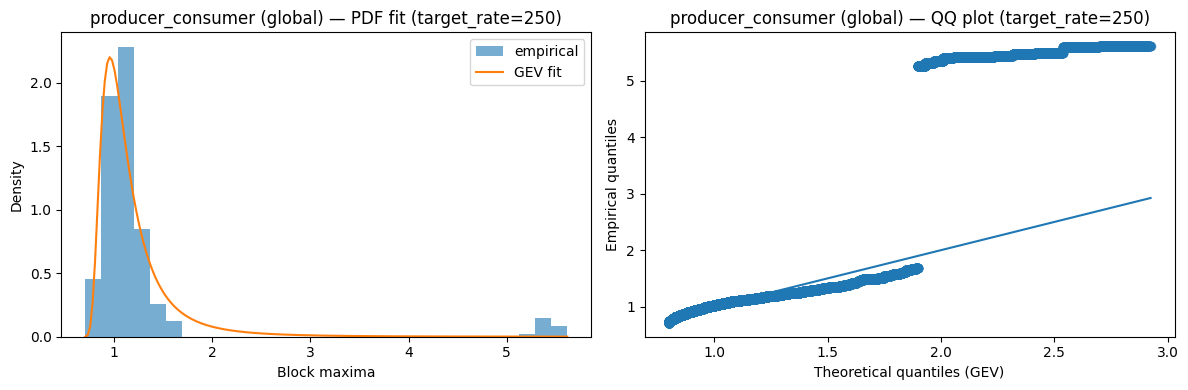

[INFO] Saved plot to /Users/soheila/PycharmProjects/PipelineProject/RealTime-Streaming-Pipeline/results/plots/plots_tr250/pdfqq_producer_consumer_global_tr250.png

Metric=consumer_application | Scope=global | TR=250 | n=100808
GEV fit: c=0.9796, loc=0.0200, scale=0.0000 | KS D=0.0239, p=0.0000


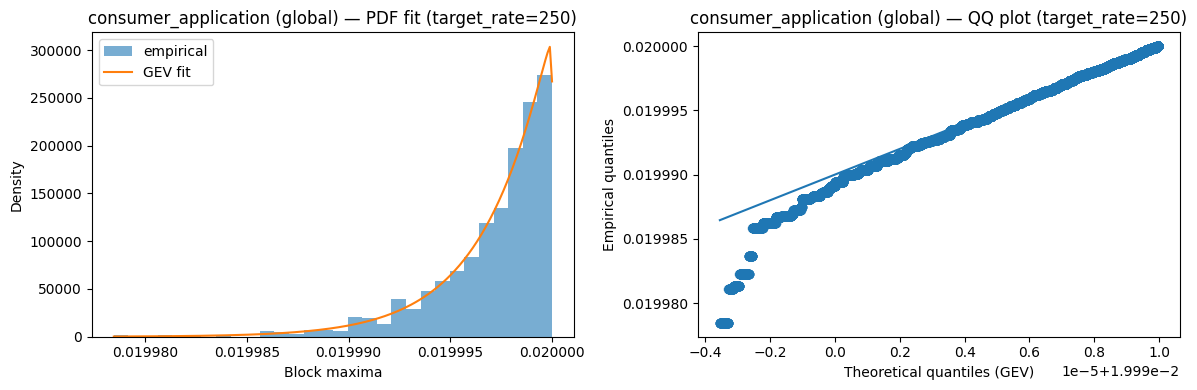

[INFO] Saved plot to /Users/soheila/PycharmProjects/PipelineProject/RealTime-Streaming-Pipeline/results/plots/plots_tr250/pdfqq_consumer_application_global_tr250.png

Metric=producer_application | Scope=global | TR=250 | n=100808
GEV fit: c=-0.3317, loc=1.0209, scale=0.1756 | KS D=0.1009, p=0.0000


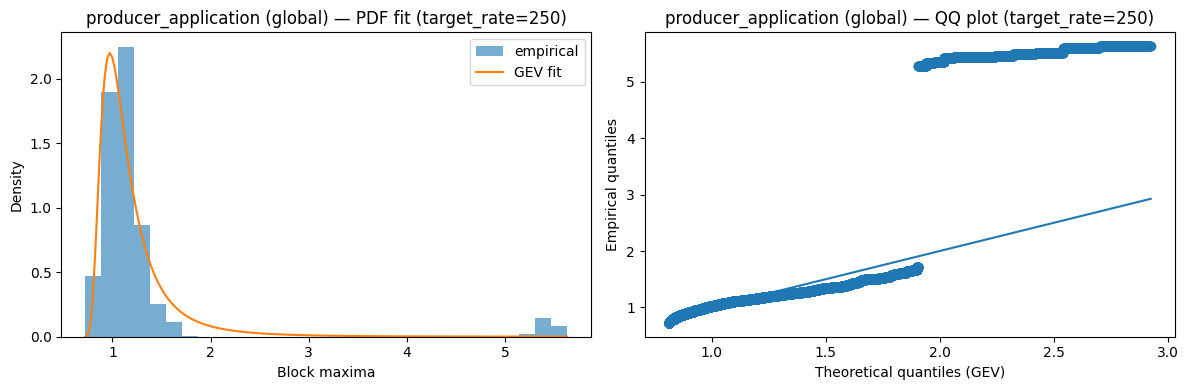

[INFO] Saved plot to /Users/soheila/PycharmProjects/PipelineProject/RealTime-Streaming-Pipeline/results/plots/plots_tr250/pdfqq_producer_application_global_tr250.png


In [160]:
#!/usr/bin/env python3
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import genextreme, kstest

# -----------------------------
# USER PATHS (edit these two)
# -----------------------------
Home         = "/Users/soheila/PycharmProjects/PipelineProject/RealTime-Streaming-Pipeline/results"
RUN_STAMP    = "20250902_063935"  # the run that produced BOTH parquet + block_maxima.csv
TR           = 250                # target_rate to filter on

# Folders for THIS run
PARQUET_ROOT = os.path.join(Home, RUN_STAMP, "consumer", "consumer-sts-0_consumer-result")
metrics_dir  = os.path.join(Home, RUN_STAMP, "merge", "merge-sts-0_merge-metrics")
block_path   = os.path.join(metrics_dir, "block_maxima.csv")

trim_levels   = [0.00, 0.01, 0.02, 0.05, 0.07, 0.10] 
# -----------------------------
# Helpers
# -----------------------------
def list_parquet_files(root: str):
    out = []
    for r, _, fs in os.walk(root):
        for f in fs:
            if f.endswith(".parquet") and not f.startswith(".tmp_"):
                out.append(os.path.join(r, f))
    return sorted(out)

def load_parquet_columns(parquet_path: str, needed_cols):
    """Read only available columns; try pyarrow for schema first."""
    needed = set(needed_cols)
    try:
        import pyarrow.parquet as pq
        have = set(pq.read_schema(parquet_path).names)
        cols = list(needed & have)
        if not cols:
            return pd.DataFrame()
        return pd.read_parquet(parquet_path, columns=cols)
    except Exception:
        try:
            df = pd.read_parquet(parquet_path)
            keep = list(needed & set(df.columns))
            return df[keep] if keep else pd.DataFrame()
        except Exception as e2:
            print(f"[ERROR] Failed to read {os.path.basename(parquet_path)}: {e2}")
            return None

def build_block_metadata_map(root: str) -> pd.DataFrame:
    """
    Scan all parquet files under `root` and build a per-block table
    keyed by block_id (basename without .parquet) with columns like target_rate.
    """
    files = list_parquet_files(root)
    if not files:
        return pd.DataFrame()

    rows = []
    for p in files:
        fn = os.path.basename(p)
        block_id = os.path.splitext(fn)[0]
        df = load_parquet_columns(p, needed_cols={"target_rate"})
        if df is None or df.empty or "target_rate" not in df.columns:
            # still record an entry so we can diagnose later
            rows.append({"block_id": block_id, "target_rate": np.nan})
            continue
        tr = pd.to_numeric(df["target_rate"], errors="coerce").dropna()
        tr_mode = float(tr.mode().iloc[0]) if not tr.empty else np.nan
        rows.append({"block_id": block_id, "target_rate": tr_mode})

    meta = pd.DataFrame(rows).drop_duplicates(subset=["block_id"], keep="last")
    meta["block_id"] = meta["block_id"].astype(str)
    meta = meta.set_index("block_id")
    return meta


# -----------------------------
# Load + Merge + Filter
# -----------------------------
if not os.path.exists(block_path):
    raise FileNotFoundError(f"block_maxima.csv not found at: {block_path}")

block_df = pd.read_csv(block_path)

# Ensure a block_id exists (basename without .parquet)
if "block_id" not in block_df.columns:
    if "file_name" not in block_df.columns:
        raise ValueError("block_maxima.csv missing both 'block_id' and 'file_name'.")
    block_df["block_id"] = (
        block_df["file_name"].astype(str).str.replace(r"\.parquet$", "", regex=True)
    )
    print("[INFO] Derived block_id from file_name.")
block_df["block_id"] = block_df["block_id"].astype(str)

# Get per-block target_rate from THIS RUN's parquet tree
meta_df = build_block_metadata_map(PARQUET_ROOT)
if meta_df is None or meta_df.empty:
    print("⚠️  Could not build parquet metadata; proceeding without target_rate filter.")
else:
    # merge on block_id
    block_df = block_df.merge(meta_df, left_on="block_id", right_index=True, how="left")
    if "target_rate" in block_df.columns:
        block_df["target_rate"] = pd.to_numeric(block_df["target_rate"], errors="coerce")
    print("[INFO] After merge, target_rate value counts (top 8):")
    print(block_df["target_rate"].value_counts(dropna=False).head(8))

# Filter by target_rate
if "target_rate" in block_df.columns:
    before = len(block_df)
    block_df = block_df[block_df["target_rate"] == float(TR)]
    print(f"[INFO] Filtered by target_rate={TR}: {before} → {len(block_df)} rows")
    if len(block_df) == 0:
        # quick diagnostics
        print("[DEBUG] Unique target_rate values present:")
        print(block_df["target_rate"].unique())
else:
    print("⚠️  target_rate column missing after merge; no TR filter applied.")

# Scope filter
scope_to_use = "global"
if "scope" in block_df.columns:
    block_df = block_df[block_df["scope"] == scope_to_use]
else:
    print("⚠️  'scope' column missing; skipping scope filter.")

print(f"[INFO] Rows after all filters: {len(block_df)}")

if len(block_df) == 0:
    raise SystemExit("[STOP] No data left after filters (check RUN_STAMP, PARQUET_ROOT, or TR).")

# -----------------------------
# Fit & Plot per metric
# -----------------------------
metrics = ["producer_consumer", "consumer_application", "producer_application"]
plot_dir = os.path.join(Home,"plots", f"plots_tr{TR}")
os.makedirs(plot_dir, exist_ok=True)

for metric in metrics:
    mask = (block_df["metric"] == metric)
    nrows = int(mask.sum())
    if nrows == 0:
        print(f"⚠️  No rows for metric={metric} at scope={scope_to_use}.")
        continue

    data = block_df.loc[mask, "block_max_value"].dropna().astype(float).values
    if len(data) < 5:
        print(f"⚠️  Not enough data for metric={metric} (n={len(data)}). Skipping.")
        continue

    # Fit GEV + KS
    c, loc, scale = genextreme.fit(data)
    D, p = kstest(data, 'genextreme', args=(c, loc, scale))
    print(f"\nMetric={metric} | Scope={scope_to_use} | TR={TR} | n={len(data)}")
    print(f"GEV fit: c={c:.4f}, loc={loc:.4f}, scale={scale:.4f} | KS D={D:.4f}, p={p:.4f}")

    # ---- Plot (one figure per metric) ----
    fig = plt.figure(figsize=(12, 4))

    # Left: histogram + fitted PDF
    ax1 = plt.subplot(1, 2, 1)
    x = np.linspace(float(np.min(data)), float(np.max(data)), 200)
    pdf = genextreme.pdf(x, c, loc=loc, scale=scale)
    ax1.hist(data, bins=30, density=True, alpha=0.6, label="empirical")
    ax1.plot(x, pdf, label="GEV fit")
    ax1.set_title(f"{metric} ({scope_to_use}) — PDF fit (target_rate={TR})")
    ax1.set_xlabel("Block maxima")
    ax1.set_ylabel("Density")
    ax1.legend()

    # Right: QQ-plot
    ax2 = plt.subplot(1, 2, 2)
    emp_q = np.sort(data)
    theo_q = genextreme.ppf(np.linspace(0.01, 0.99, len(emp_q)), c, loc=loc, scale=scale)
    ax2.scatter(theo_q, emp_q, alpha=0.6)
    lo, hi = np.nanmin(theo_q), np.nanmax(theo_q)
    ax2.plot([lo, hi], [lo, hi])
    ax2.set_title(f"{metric} ({scope_to_use}) — QQ plot (target_rate={TR})")
    ax2.set_xlabel("Theoretical quantiles (GEV)")
    ax2.set_ylabel("Empirical quantiles")

    plt.tight_layout()

    out_path = os.path.join(plot_dir, f"pdfqq_{metric}_{scope_to_use}_tr{TR}.png")
    plt.savefig(out_path, dpi=150)
    plt.show()
    print(f"[INFO] Saved plot to {out_path}")
